### Build a basic chatbot with Langgraph (graph api)

In [1]:
from typing import Annotated 
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [12]:
import os 
from dotenv import load_dotenv 
load_dotenv(verbose=True)

True

In [13]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama-3.1-8b-instant")

In [14]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [15]:
graph_builder=StateGraph(State)

### adding node
graph_builder.add_node("llmchatbot",chatbot)

### adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

### compile the graph
graph=graph_builder.compile()

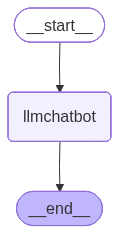

In [16]:
### visualize the graph 
from IPython.display import display, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [40]:
response=graph.invoke({"messages":"hi there, how are you doing today?"})

In [43]:
response["messages"][-1].content

"I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm always happy to chat with you and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?"

In [47]:
for event in graph.stream({"messages":"hi there, how are you doing today?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm always happy to chat with you and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?


In [18]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is Langchain?")

{'query': 'What is Langchain?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aws.amazon.com/what-is/langchain',
   'title': 'What is LangChain?',
   'content': 'LangChain is an open source framework for building applications based on large language models (LLMs). LLMs are large deep-learning models pre-trained on large amounts of data that can generate responses to user queries—for example, answering questions or creating images from text-based prompts. LangChain provides tools and abstractions to improve the customization, accuracy, and relevancy of the information the models generate. For example, developers can use LangChain components to build new prompt chains or customize existing templates. To do that, machine learning engineers must integrate the LLM with the organization’s internal data sources and apply *prompt engineering*—a practice where a data scientist refines inputs to a generative model with a specific structure and contex

In [ ]:
## Custom Function 
